# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Jordan Sebastian Simatupang | 5054251038 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OrdinalEncoder

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
data = pd.read_csv('bankruptcy.csv')
data.columns = data.columns.str.strip()
print("Ukuran dataset:", data.shape)
print("Tipe data:")
data.info()
print("Statistik deskriptif:")
numeric_data = data.select_dtypes(include="number")
stat_deskrip = data.describe().T
stat_deskrip["median"] = numeric_data.median()
stat_deskrip["modus"] = numeric_data.mode().iloc[0]
display(stat_deskrip)
print("Jumlah missing value:")
data.isnull().sum().sum()

Ukuran dataset: (6819, 96)
Tipe data:
<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   A

,count,mean,std,min,25%,50%,75%,max,median,modus
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0,0.000000,0.000000
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0,0.502706,0.490128
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0,0.559802,0.559693
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0,0.552278,0.538787
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0,0.605997,0.598956
...,...,...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0,0.278778,0.000000
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0,0.026808,0.026791
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0,0.565252,0.565158
Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000


Jumlah missing value:


np.int64(0)

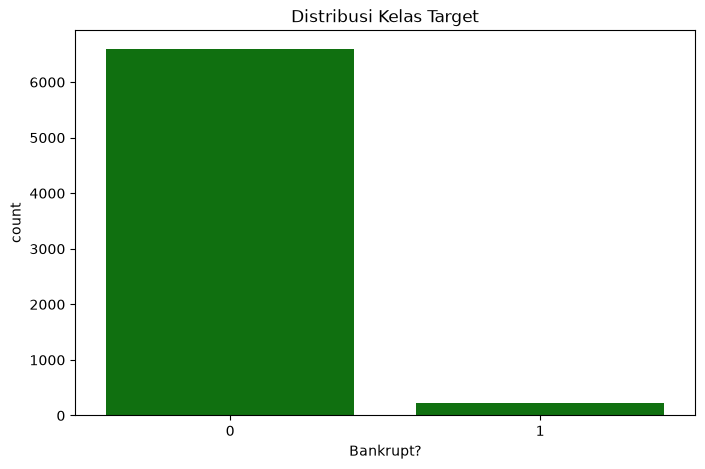

In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="Bankrupt?", color="green")
plt.title("Distribusi Kelas Target")
plt.show()

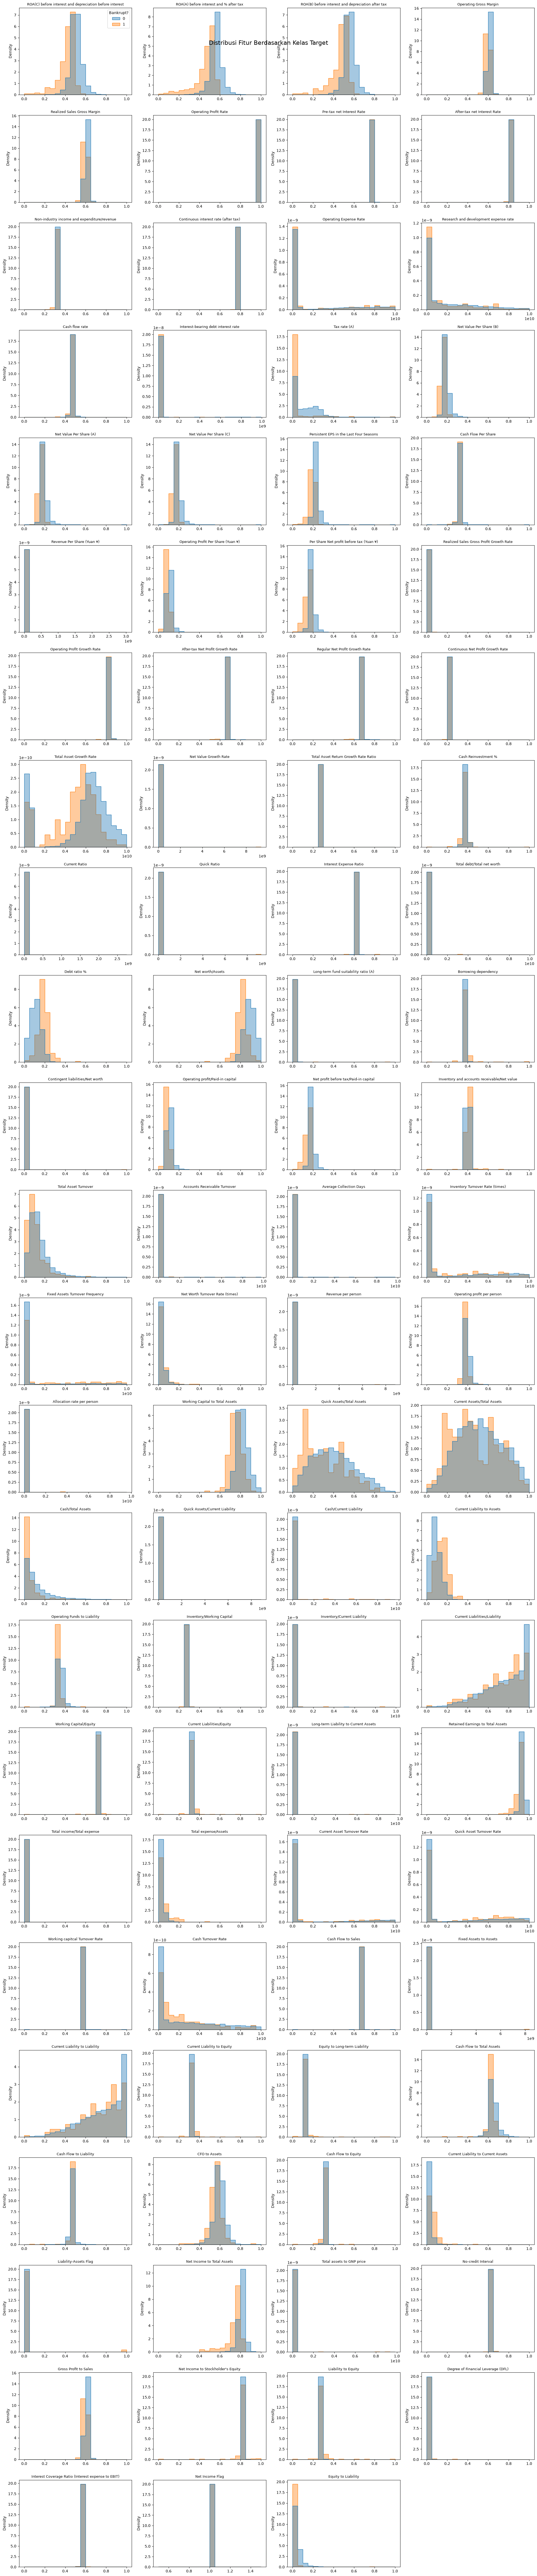

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.
feature_columns = data.drop(columns=["Bankrupt?"]).columns
n_columns = 4
n_rows = int(np.ceil(len(feature_columns) / n_columns))

fig, axes = plt.subplots(n_rows, n_columns, figsize=(20, n_rows * 4))
axes = np.array(axes).reshape(-1)

for index, feature in enumerate(feature_columns):
    sns.histplot(
        data=data,
        x=feature,
        hue="Bankrupt?",
        bins=20,
        element="step",
        stat="density",
        common_norm=False,
        alpha=0.4,
        ax=axes[index],
        legend=(index == 0)
    )
    axes[index].set_title(feature, fontsize=9)
    axes[index].set_xlabel("")
    axes[index].set_ylabel("Density")

for axis in axes[len(feature_columns):]:
    axis.set_visible(False)

fig.suptitle("Distribusi Fitur Berdasarkan Kelas Target", fontsize=16)
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [5]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
print("data missing:", data.isnull().sum().sum())

data missing: 0


In [6]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = data.drop(columns=["Bankrupt?"])
y = data["Bankrupt?"]

constant_cols = [col for col in X.columns if X[col].nunique() == 1]
print("Kolom konstan yang dihapus:", constant_cols)
X = X.drop(columns=constant_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test : {X_test.shape}")

Kolom konstan yang dihapus: ['Net Income Flag']
Ukuran X_train: (5455, 94)
Ukuran X_test : (1364, 94)


In [7]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.
categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()
print("Kolom kategorikal:", categorical_cols)

if categorical_cols:
    encoder = OrdinalEncoder()
    X[categorical_cols] = encoder.fit_transform(X[categorical_cols])
    print("Encoding berhasil")
else:
    print("Tidak ada kolom kategorikal")

Kolom kategorikal: []
Tidak ada kolom kategorikal


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [8]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.
dt_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
dt_gini.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [9]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_gini = dt_gini.predict(X_test)

## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [10]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.
dt_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt_entropy.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [11]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_entropy = dt_entropy.predict(X_test)

## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [12]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).
depth_values = [2, 3, 5, 7, 10, 15, None]
train_acc = []
test_acc = []
test_f1 = []

In [13]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
for depth in depth_values:
    dt = DecisionTreeClassifier(
        criterion="gini", max_depth=depth, random_state=42
    )
    dt.fit(X_train, y_train)

    # Prediksi train & test
    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)

    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))
    test_f1.append(
        f1_score(y_test, y_test_pred, pos_label=1)
    )

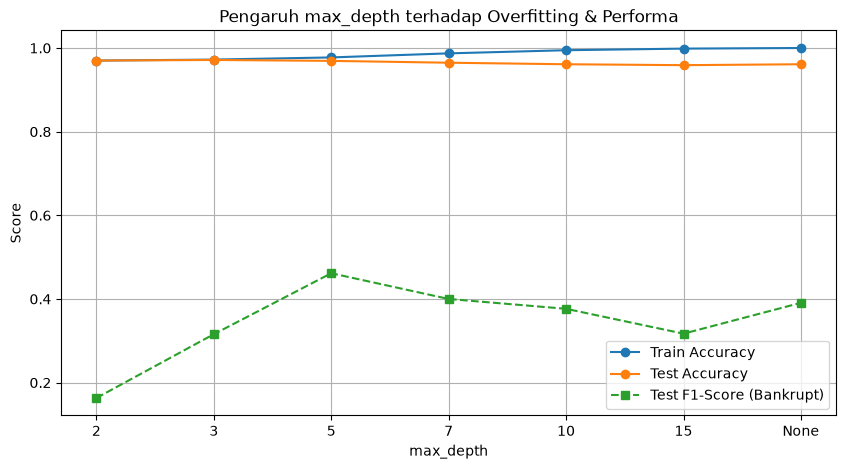

In [14]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.figure(figsize=(10, 5))
plt.plot(
    [str(d) for d in depth_values],
    train_acc,
    marker="o",
    label="Train Accuracy",
)
plt.plot(
    [str(d) for d in depth_values], test_acc, marker="o", label="Test Accuracy"
)
plt.plot(
    [str(d) for d in depth_values],
    test_f1,
    marker="s",
    linestyle="--",
    label="Test F1-Score (Bankrupt)",
)
plt.xlabel("max_depth")
plt.ylabel("Score")
plt.title("Pengaruh max_depth terhadap Overfitting & Performa")
plt.legend()
plt.grid(True)
plt.show()

# 4. Evaluasi Model

In [15]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
metrics_gini = {
    "Model": "Gini Impurity",
    "Accuracy": accuracy_score(y_test, y_pred_gini),
    "Precision": precision_score(y_test, y_pred_gini),
    "Recall": recall_score(y_test, y_pred_gini),
    "F1-Score": f1_score(y_test, y_pred_gini),
}

metrics_entropy = {
    "Model": "Entropy",
    "Accuracy": accuracy_score(y_test, y_pred_entropy),
    "Precision": precision_score(y_test, y_pred_entropy),
    "Recall": recall_score(y_test, y_pred_entropy),
    "F1-Score": f1_score(y_test, y_pred_entropy),
}

df_metrics = pd.DataFrame([metrics_gini, metrics_entropy])

df_metrics = df_metrics.round(4)
display(df_metrics)

,Model,Accuracy,Precision,Recall,F1-Score
0,Gini Impurity,0.9611,0.3953,0.3864,0.3908
1,Entropy,0.9589,0.3571,0.3409,0.3488


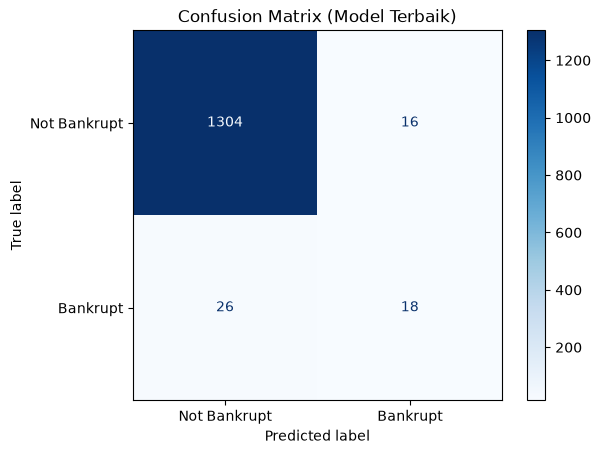

In [16]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
best_dt = DecisionTreeClassifier(
    criterion="gini", max_depth=5, random_state=42
)
best_dt.fit(X_train, y_train)
y_pred_best = best_dt.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Not Bankrupt", "Bankrupt"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Model Terbaik)")
plt.show()

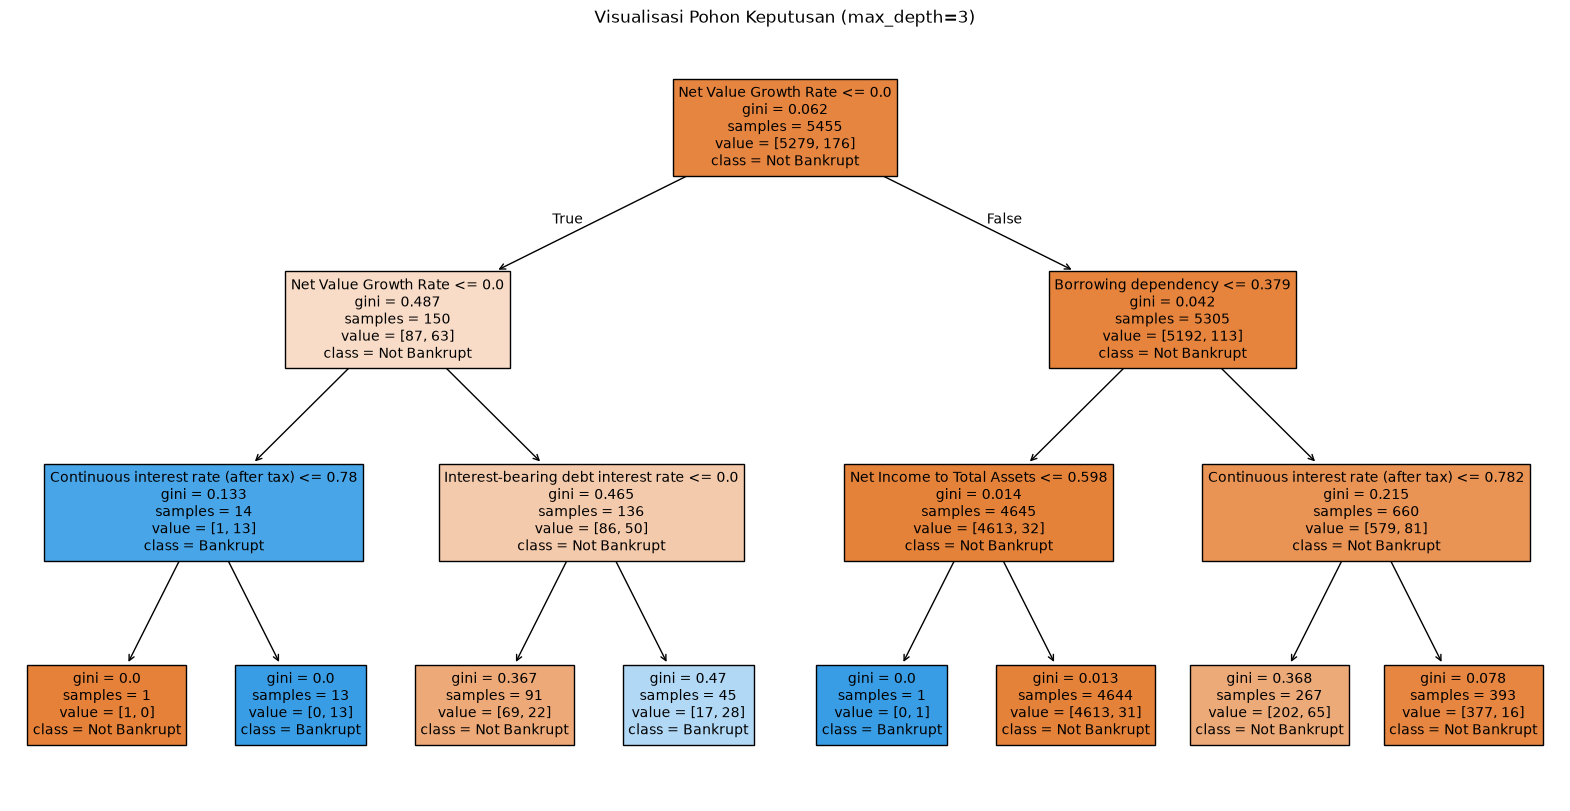

In [17]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.
dt_small = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
dt_small.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(
    dt_small,
    feature_names=X.columns,
    class_names=["Not Bankrupt", "Bankrupt"],
    filled=True,
    fontsize=10,
)
plt.title("Visualisasi Pohon Keputusan (max_depth=3)")
plt.show()

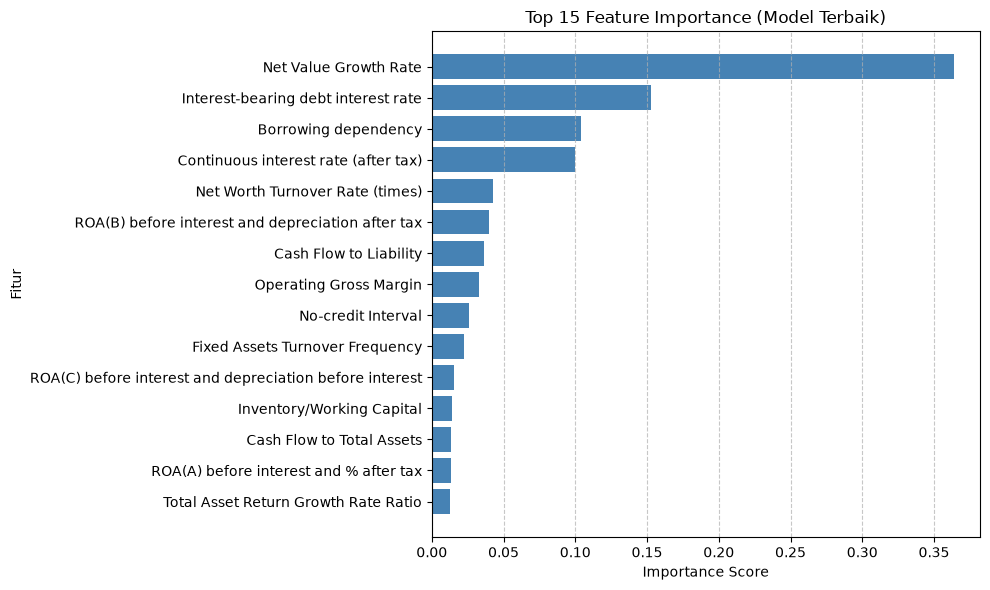

In [18]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.
importances = best_dt.feature_importances_

df_importance = pd.DataFrame(
    {"Feature": X.columns, "Importance": importances}
).sort_values(by="Importance", ascending=True)

top_15 = df_importance.tail(15)

plt.figure(figsize=(10, 6))
plt.barh(top_15["Feature"], top_15["Importance"], color="steelblue")
plt.xlabel("Importance Score")
plt.ylabel("Fitur")
plt.title("Top 15 Feature Importance (Model Terbaik)")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

Berdasarkan hasil eksperimen, model dengan kriteria **Gini** memiliki performa sedikit lebih baik daripada **Entropy**. Gini memperoleh accuracy **96,11%** dan F1-score **39,08%**, sedangkan Entropy memperoleh accuracy **95,89%** dan F1-score **34,88%**. Perbedaannya tidak terlalu besar, sehingga kedua kriteria memberikan hasil yang relatif mirip.

Pada eksperimen `max_depth`, terlihat bahwa semakin dalam pohon, accuracy training terus meningkat, tetapi accuracy testing mulai menurun. Gejala overfitting mulai terlihat setelah **max_depth=5**. Pada `max_depth=5`, accuracy training **97,75%** dan accuracy testing **96,92%**, serta F1-score kelas bangkrut mencapai **46,15%**, yang merupakan F1-score tertinggi dari nilai kedalaman yang diuji. Saat `max_depth` semakin besar, selisih performa training dan testing semakin terlihat.

Berdasarkan feature importance, fitur yang paling berpengaruh adalah **Net Value Growth Rate (36,39%)**, diikuti **Interest-bearing debt interest rate (15,30%)** dan **Borrowing dependency (10,38%)**. Hal ini menunjukkan bahwa beberapa indikator pertumbuhan nilai perusahaan dan kondisi utang memiliki pengaruh besar terhadap prediksi kebangkrutan.

Karena data tidak seimbang dan jumlah perusahaan bangkrut jauh lebih sedikit, accuracy yang tinggi belum tentu menunjukkan kemampuan yang baik dalam mendeteksi perusahaan bangkrut. Hal ini terlihat dari recall kelas bangkrut yang masih relatif rendah.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba pruning dengan ccp_alpha, membandingkan dengan model lain, atau mencoba variasi hyperparameter lain seperti min_samples_leaf), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

#### Kesimpulan

Eksperimen menunjukkan bahwa **Decision Tree dengan kriteria Gini** memberikan hasil sedikit lebih baik daripada Entropy. Pengaturan `max_depth` juga berpengaruh terhadap overfitting. Dalam percobaan ini, **max_depth=5** memberikan keseimbangan yang baik dan menghasilkan F1-score kelas bangkrut sebesar **46,15%**. Fitur yang paling berpengaruh adalah **Net Value Growth Rate**.

#### Saran

Untuk pengembangan selanjutnya, model dapat ditingkatkan dengan mencoba **pruning menggunakan `ccp_alpha`**, variasi `min_samples_leaf`, atau membandingkannya dengan model lain seperti **Random Forest**. Karena dataset tidak seimbang, evaluasi sebaiknya tidak hanya menggunakan accuracy, tetapi juga memperhatikan **precision, recall, dan F1-score**.